In [3]:
!pip install keras keras-hub --upgrade -q
import os
os.environ["KERAS_BACKEND"] = "jax"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 61.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.21.1 requires keras-hub==0.21.1, but you have keras-hub 0.23.0 which is incompatible.


In [4]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

In [5]:
from keras.datasets import cifar10

# Load the dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


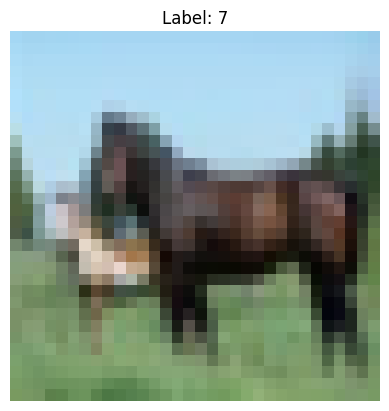

In [13]:
# Pick an index
import matplotlib.pyplot as plt
idx = 12   # change this to show other images

plt.imshow(x_train[idx])
plt.title(f"Label: {y_train[idx][0]}")
plt.axis("off")
plt.show()

In [6]:
import tensorflow as tf

# Normalize the data
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# # Resize to 224x224 for VGG
# IMG_SIZE = 224
# x_train = tf.image.resize(x_train, (IMG_SIZE, IMG_SIZE))
# x_test  = tf.image.resize(x_test,  (IMG_SIZE, IMG_SIZE))

In [5]:
import keras
from keras import layers

# Model to mirror LeNet architecture

model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(64, (3, 3), padding= 'same', activation='relu'),
    layers.Conv2D(64, (3, 3), padding= 'same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding= 'same', activation='relu'),
    layers.Conv2D(128, (3, 3), padding= 'same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), padding= 'same', activation='relu'),
    layers.Conv2D(256, (3, 3), padding= 'same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,248,202 (12.39 MB)

 Trainable params: 3,248,202 (12.39 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer= 'adam',
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [7]:
x_val = x_train[-5000:]
y_val = y_train[-5000:]
x_train = x_train[:45000]
y_train = y_train[:45000]

In [9]:
y_val[2]

array([4], dtype=uint8)

In [10]:
y_train.shape

(45000, 1)

In [11]:
history = model.fit(
    x_train,
    y_train,
    epochs=40,
    batch_size=64,
    validation_data=(x_val, y_val),
    validation_batch_size=128
)

Epoch 1/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 1061s 2s/step - accuracy: 0.4005 - loss: 1.6255 - val_accuracy: 0.5526 - val_loss: 1.2612
Epoch 2/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 1039s 1s/step - accuracy: 0.6180 - loss: 1.0761 - val_accuracy: 0.6852 - val_loss: 0.8940
Epoch 3/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 1039s 1s/step - accuracy: 0.7032 - loss: 0.8503 - val_accuracy: 0.7286 - val_loss: 0.7868
Epoch 4/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 1038s 1s/step - accuracy: 0.7551 - loss: 0.7029 - val_accuracy: 0.7686 - val_loss: 0.6735
Epoch 5/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 1040s 1s/step - accuracy: 0.7949 - loss: 0.5860 - val_accuracy: 0.7732 - val_loss: 0.6984
Epoch 6/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 1040s 1s/step - accuracy: 0.8301 - loss: 0.4875 - val_accuracy: 0.7666 - val_loss: 0.7100
Epoch 7/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 1037s 1s/step - accuracy: 0.8551 - loss: 0.4176 - val_accuracy: 0.7742 - val_loss: 0.6932
Epoch 8/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 1034s 1s/step - accuracy: 0.8752 - loss: 0.3535 - 

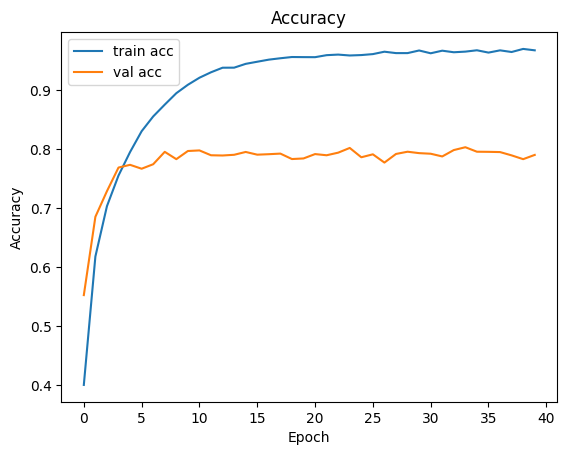

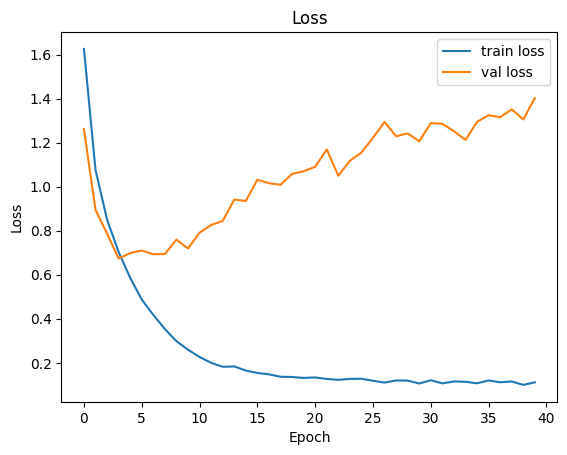

In [12]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [9]:
# Model to mirror LeNet architecture
import keras
from keras import layers

new_model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(64, (3, 3), padding= 'same', activation='relu'),
    layers.Conv2D(64, (3, 3), padding= 'same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding= 'same', activation='relu'),
    layers.Conv2D(128, (3, 3), padding= 'same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), padding= 'same', activation='relu'),
    layers.Conv2D(256, (3, 3), padding= 'same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

new_model.compile(
    optimizer= 'adam',
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

new_history = new_model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=64,
    validation_data=(x_val, y_val),
    validation_batch_size=128
)

Epoch 1/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 928s 1s/step - accuracy: 0.2804 - loss: 1.9153 - val_accuracy: 0.5636 - val_loss: 1.2133
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 924s 1s/step - accuracy: 0.5728 - loss: 1.1950 - val_accuracy: 0.6358 - val_loss: 1.0579
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 942s 1s/step - accuracy: 0.6694 - loss: 0.9390 - val_accuracy: 0.7208 - val_loss: 0.7898


In [10]:
#output model

new_model.save('CNN_cifar10_06694_VGG.keras')